# 04. Диагностика потерянного сигнала `Q_B1` / `Q_B2` — V1

## Главный исследовательский вопрос

**Содержат ли закрытые индексы `Q_B1_norm` и `Q_B2_norm` дополнительный сигнал именно в тех дефолтах, которые baseline без этих индексов согласованно ставит слишком низко по риску, и какой из двух индексов сильнее связан с этим информационным пробелом?**

### Контекст

Stage 1 зафиксировал честный baseline без закрытых индексов: **Gini ≈ 0.804**.

Stage 2 показал, что CatBoost, XGBoost и LightGBM опираются на очень похожее ядро доступных признаков.

Stage 3 показал, что:

- из 28 015 дефолтов **1 278** попали ниже медианы consensus-риска;
- **805** из этих 1 278 случаев являются общей слепой зоной: три модели ошибаются согласованно;
- сильное межмодельное расхождение есть лишь у **1.9%** глубоко пропущенных дефолтов;
- значит, следующий вопрос логично адресовать не модели, а **потерянному информационному сигналу**.

### Роль закрытых индексов

По подтверждённому бизнес-контексту проекта:

- `Q_B1_norm` — закрытый индекс СПАРК ИФР;
- `Q_B2_norm` — закрытый индекс СПАРК ИДО.

**Они запрещены в финальной рабочей модели.**

В этом notebook они используются только как **диагностический oracle/reference**: мы хотим понять, какой тип закрытого сигнала видит риск там, где 47 допустимых признаков его не видят.

### Что НЕ делаем

- не добавляем `Q_B1_norm` / `Q_B2_norm` в финальный feature set;
- не выбираем новую модель;
- не подбираем гиперпараметры;
- не подбираем threshold;
- не открываем final test;
- не называем закрытые индексы причинными факторами дефолта.


In [1]:
from __future__ import annotations

import hashlib
import importlib.metadata as importlib_metadata
import json
import platform
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import train_test_split


def найти_корень_проекта(начало: Path | None = None) -> Path:
    """Находит корень проекта по pyproject.toml."""
    текущая = (начало or Path.cwd()).resolve()
    for кандидат in [текущая, *текущая.parents]:
        if (кандидат / "pyproject.toml").exists():
            return кандидат
    raise FileNotFoundError("Не найден корень проекта с pyproject.toml.")


def вычислить_sha256(путь: Path, размер_блока: int = 1024 * 1024) -> str:
    """Вычисляет SHA-256 файла блоками."""
    хэш = hashlib.sha256()
    with путь.open("rb") as файл:
        for блок in iter(lambda: файл.read(размер_блока), b""):
            хэш.update(блок)
    return хэш.hexdigest()


def хэш_массива(значения: np.ndarray) -> str:
    """Вычисляет SHA-256 массива индексов."""
    массив = np.asarray(значения, dtype=np.int64)
    return hashlib.sha256(массив.tobytes()).hexdigest()


КОРЕНЬ_ПРОЕКТА = найти_корень_проекта()
ПУТЬ_К_ДАТАСЕТУ = КОРЕНЬ_ПРОЕКТА / "data" / "raw" / "Data_final.xlsb"
ПАПКА_ОТЧЁТОВ = КОРЕНЬ_ПРОЕКТА / "reports" / "generated"
ПУТЬ_OOF = ПАПКА_ОТЧЁТОВ / "stage3_oof_predictions_V1.npz"

ОЖИДАЕМЫЙ_SHA_DATASET = "fc742be66d238c529daba52ccc755f774f836b7d052ed062cdf0b345080e7930"
ОЖИДАЕМЫЙ_SHA_РАБОТА = "80430ce6290d0982d3641621ba1ed62f6fb495e8d32f7d23d9fca00091aadb45"
ОЖИДАЕМЫЙ_SHA_TEST = "35ec963fe82918841f4a8acb012e8fc878aed66d2c5296ea6cb105177cafbb37"
ОЖИДАЕМЫЙ_SHA_OOF = "faa53a8aed86c2d445699c0fd1df6a5b83711c96d3a300f9a8860112ff4473ac"

ЦЕЛЕВАЯ_ПЕРЕМЕННАЯ = "DefMark"
ЗАКРЫТЫЕ_ИНДЕКСЫ = ["Q_B1_norm", "Q_B2_norm"]

ДОЛЯ_ФИНАЛЬНОГО_TEST = 0.20
СЛУЧАЙНОЕ_ЗЕРНО = 42

ГРАНИЦА_ГЛУБОКОГО_ПРОПУСКА = 0.50
ГРАНИЦА_ХОРОШЕГО_ДЕФОЛТА = 0.90
МАКС_РАЗБРОС_ОБЩЕЙ_СЛЕПОЙ_ЗОНЫ = 0.10

ОЖИДАЕМЫЙ_GINI_V2 = {
    "CatBoost": 0.803779690692136,
    "XGBoost": 0.8039898778800276,
    "LightGBM": 0.8033629488861926,
}

print("Корень проекта:", КОРЕНЬ_ПРОЕКТА)
print("Python:", platform.python_version())
print("Dataset:", ПУТЬ_К_ДАТАСЕТУ)
print("OOF checkpoint:", ПУТЬ_OOF)

Корень проекта: D:\Projects\komus-credit-risk
Python: 3.12.2
Dataset: D:\Projects\komus-credit-risk\data\raw\Data_final.xlsb
OOF checkpoint: D:\Projects\komus-credit-risk\reports\generated\stage3_oof_predictions_V1.npz


### Анализ настройки

Главный предохранитель этого эксперимента — **никакого переобучения baseline**. Мы используем row-level OOF checkpoint, сохранённый Stage 3, и проверяем его SHA-256.

Это делает Stage 4 быстрым и не создаёт новый вариант модели только ради диагностического анализа.


# 1. Gate идентичности данных и OOF checkpoint

## Исследовательский вопрос

Действительно ли мы анализируем тот же dataset, тот же working split и те же OOF-прогнозы, на которых был принят Stage 3?


In [2]:
if not ПУТЬ_К_ДАТАСЕТУ.exists():
    raise FileNotFoundError(f"Dataset не найден: {ПУТЬ_К_ДАТАСЕТУ}")

if not ПУТЬ_OOF.exists():
    raise FileNotFoundError(
        "Не найден Stage 3 OOF checkpoint:\n"
        f"{ПУТЬ_OOF}\n"
        "Сначала должен быть успешно выполнен Stage 3 V1."
    )

sha_dataset = вычислить_sha256(ПУТЬ_К_ДАТАСЕТУ)
sha_oof = вычислить_sha256(ПУТЬ_OOF)

if sha_dataset.lower() != ОЖИДАЕМЫЙ_SHA_DATASET.lower():
    raise RuntimeError(
        "Dataset не совпал с зафиксированной версией.\n"
        f"Ожидался: {ОЖИДАЕМЫЙ_SHA_DATASET}\n"
        f"Получен:  {sha_dataset}"
    )

if sha_oof.lower() != ОЖИДАЕМЫЙ_SHA_OOF.lower():
    raise RuntimeError(
        "OOF checkpoint не совпал с Stage 3 V1.\n"
        f"Ожидался: {ОЖИДАЕМЫЙ_SHA_OOF}\n"
        f"Получен:  {sha_oof}"
    )

данные = pd.read_excel(
    ПУТЬ_К_ДАТАСЕТУ,
    engine="pyxlsb",
    sheet_name="Data_final",
    usecols=[ЦЕЛЕВАЯ_ПЕРЕМЕННАЯ, *ЗАКРЫТЫЕ_ИНДЕКСЫ],
).reset_index(drop=True)

for столбец in [ЦЕЛЕВАЯ_ПЕРЕМЕННАЯ, *ЗАКРЫТЫЕ_ИНДЕКСЫ]:
    данные[столбец] = pd.to_numeric(данные[столбец], errors="raise")

if данные[ЗАКРЫТЫЕ_ИНДЕКСЫ].isna().any().any():
    raise RuntimeError("В закрытых индексах обнаружены пропуски.")

индексы = np.arange(len(данные))
индексы_работа_контроль, индексы_test_контроль = train_test_split(
    индексы,
    test_size=ДОЛЯ_ФИНАЛЬНОГО_TEST,
    stratify=данные[ЦЕЛЕВАЯ_ПЕРЕМЕННАЯ],
    random_state=СЛУЧАЙНОЕ_ЗЕРНО,
)

if хэш_массива(индексы_работа_контроль) != ОЖИДАЕМЫЙ_SHA_РАБОТА:
    raise RuntimeError("Working split не совпал с принятым протоколом.")

if хэш_массива(индексы_test_контроль) != ОЖИДАЕМЫЙ_SHA_TEST:
    raise RuntimeError("Final test split не совпал с принятым протоколом.")

with np.load(ПУТЬ_OOF) as checkpoint:
    working_indices = np.asarray(checkpoint["working_indices"], dtype=np.int64)
    target = np.asarray(checkpoint["target"], dtype=np.int8)
    oof_catboost = np.asarray(checkpoint["oof_catboost"], dtype=np.float64)
    oof_xgboost = np.asarray(checkpoint["oof_xgboost"], dtype=np.float64)
    oof_lightgbm = np.asarray(checkpoint["oof_lightgbm"], dtype=np.float64)
    consensus_rank = np.asarray(checkpoint["consensus_rank"], dtype=np.float64)
    rank_spread = np.asarray(checkpoint["rank_spread"], dtype=np.float64)

if хэш_массива(working_indices) != ОЖИДАЕМЫЙ_SHA_РАБОТА:
    raise RuntimeError("working_indices в OOF checkpoint имеют неожиданный SHA.")

if not np.array_equal(working_indices, индексы_работа_контроль):
    raise RuntimeError("Порядок working_indices не совпал с воспроизведённым split.")

target_dataset = (
    данные.iloc[working_indices][ЦЕЛЕВАЯ_ПЕРЕМЕННАЯ]
    .to_numpy(dtype=np.int8)
)

if not np.array_equal(target, target_dataset):
    raise RuntimeError("Target в OOF checkpoint не совпал с dataset.")

if not (
    len(target)
    == len(oof_catboost)
    == len(oof_xgboost)
    == len(oof_lightgbm)
    == len(consensus_rank)
    == len(rank_spread)
):
    raise RuntimeError("Массивы OOF checkpoint имеют разные длины.")

ПАСПОРТ = pd.DataFrame([
    ("SHA dataset", sha_dataset),
    ("SHA OOF checkpoint", sha_oof),
    ("Working rows", len(working_indices)),
    ("Final test rows", len(индексы_test_контроль)),
    ("Пропуски Q_B1/Q_B2", int(данные[ЗАКРЫТЫЕ_ИНДЕКСЫ].isna().sum().sum())),
], columns=["Проверка", "Значение"])

display(ПАСПОРТ)
print("Final test зафиксирован, но не используется.")

,Проверка,Значение
0,SHA dataset,fc742be66d238c529daba52ccc755f774f836b7d052ed0...
1,SHA OOF checkpoint,faa53a8aed86c2d445699c0fd1df6a5b83711c96d3a300...
2,Working rows,289614
3,Final test rows,72404
4,Пропуски Q_B1/Q_B2,0


Final test зафиксирован, но не используется.


# 2. Gate воспроизводимости OOF

## Исследовательский вопрос

Соответствуют ли сохранённые OOF-прогнозы принятому Stage 1 V2?

Если нет — дальнейший анализ закрытых индексов останавливается.


In [3]:
OOF = {
    "CatBoost": oof_catboost,
    "XGBoost": oof_xgboost,
    "LightGBM": oof_lightgbm,
}

строки_качества = []

for название, вероятности in OOF.items():
    roc_auc = float(roc_auc_score(target, вероятности))
    gini = float(2 * roc_auc - 1)
    pr_auc = float(average_precision_score(target, вероятности))
    отклонение = float(gini - ОЖИДАЕМЫЙ_GINI_V2[название])

    if abs(отклонение) > 1e-6:
        raise RuntimeError(
            f"{название}: OOF Gini checkpoint отличается от Stage 1 V2 "
            f"на {отклонение:+.8f}."
        )

    строки_качества.append({
        "Модель": название,
        "Gini OOF": gini,
        "PR-AUC OOF": pr_auc,
        "Отклонение Gini": отклонение,
    })

ТАБЛИЦА_КАЧЕСТВА = pd.DataFrame(строки_качества)
display(ТАБЛИЦА_КАЧЕСТВА.round(6))

ранги_пересчёт = np.column_stack([
    pd.Series(oof_catboost).rank(method="average", pct=True).to_numpy(),
    pd.Series(oof_xgboost).rank(method="average", pct=True).to_numpy(),
    pd.Series(oof_lightgbm).rank(method="average", pct=True).to_numpy(),
])

consensus_пересчёт = ранги_пересчёт.mean(axis=1)
spread_пересчёт = ранги_пересчёт.max(axis=1) - ранги_пересчёт.min(axis=1)

if not np.allclose(consensus_rank, consensus_пересчёт, atol=1e-12):
    raise RuntimeError("Consensus rank checkpoint не воспроизвёлся.")

if not np.allclose(rank_spread, spread_пересчёт, atol=1e-12):
    raise RuntimeError("Rank spread checkpoint не воспроизвёлся.")

print("OOF checkpoint полностью воспроизвёл Stage 1/3.")

,Модель,Gini OOF,PR-AUC OOF,Отклонение Gini
0,CatBoost,0.803780,0.600961,0.0
1,XGBoost,0.803990,0.599273,0.0
2,LightGBM,0.803363,0.597750,0.0


OOF checkpoint полностью воспроизвёл Stage 1/3.


# 3. Восстановление Stage 3 blind spot

## Исследовательский вопрос

Получаем ли мы ровно те же диагностические группы, которые были зафиксированы в Stage 3?

Это важный gate: закрытые индексы должны анализироваться **на уже определённой слепой зоне**, а не использоваться для её переопределения.


In [4]:
маска_дефолт = target == 1
маска_недефолт = ~маска_дефолт

маска_глубокий_пропуск = (
    маска_дефолт
    & (consensus_rank <= ГРАНИЦА_ГЛУБОКОГО_ПРОПУСКА)
)

маска_хороший_дефолт = (
    маска_дефолт
    & (consensus_rank >= ГРАНИЦА_ХОРОШЕГО_ДЕФОЛТА)
)

маска_общая_слепая_зона = (
    маска_глубокий_пропуск
    & (rank_spread <= МАКС_РАЗБРОС_ОБЩЕЙ_СЛЕПОЙ_ЗОНЫ)
)

ожидаемые_группы = {
    "Всего дефолтов": 28015,
    "Глубоко пропущенные дефолты": 1278,
    "Общая слепая зона": 805,
    "Хорошо ранжированные дефолты": 16026,
}

фактические_группы = {
    "Всего дефолтов": int(маска_дефолт.sum()),
    "Глубоко пропущенные дефолты": int(маска_глубокий_пропуск.sum()),
    "Общая слепая зона": int(маска_общая_слепая_зона.sum()),
    "Хорошо ранжированные дефолты": int(маска_хороший_дефолт.sum()),
}

if фактические_группы != ожидаемые_группы:
    raise RuntimeError(
        "Диагностические группы Stage 3 не воспроизвелись.\n"
        f"Ожидалось: {ожидаемые_группы}\n"
        f"Получено: {фактические_группы}"
    )

ТАБЛИЦА_ГРУПП = pd.DataFrame([
    {"Группа": группа, "Число": число}
    for группа, число in фактические_группы.items()
])

display(ТАБЛИЦА_ГРУПП)
print("Blind spot Stage 3 воспроизведён без использования Q_B1/Q_B2.")

,Группа,Число
0,Всего дефолтов,28015
1,Глубоко пропущенные дефолты,1278
2,Общая слепая зона,805
3,Хорошо ранжированные дефолты,16026


Blind spot Stage 3 воспроизведён без использования Q_B1/Q_B2.


# 4. Самостоятельный сигнал закрытых индексов

## Исследовательский вопрос

Насколько сильно каждый закрытый индекс связан с target на **working sample**, если рассматривать его отдельно от baseline?

Ориентация индекса нужна только для удобного понятия «чем выше rank, тем выше наблюдаемый риск». Мы выбираем знак на working sample и явно фиксируем это как диагностическое преобразование — не как production-настройку.


In [5]:
закрытые_work = (
    данные.iloc[working_indices][ЗАКРЫТЫЕ_ИНДЕКСЫ]
    .reset_index(drop=True)
    .astype("float64")
)

РИСК_РАНГИ: dict[str, np.ndarray] = {}
строки_индексов: list[dict[str, Any]] = []

for признак in ЗАКРЫТЫЕ_ИНДЕКСЫ:
    значения = закрытые_work[признак].to_numpy(dtype=np.float64)
    auc_прямой = float(roc_auc_score(target, значения))

    if auc_прямой >= 0.5:
        риск_score = значения
        ориентация = "больше = выше наблюдаемый риск"
    else:
        риск_score = -значения
        ориентация = "меньше = выше наблюдаемый риск"

    риск_rank = (
        pd.Series(риск_score)
        .rank(method="average", pct=True)
        .to_numpy(dtype=np.float64)
    )

    РИСК_РАНГИ[признак] = риск_rank

    roc_auc = float(roc_auc_score(target, риск_rank))
    строки_индексов.append({
        "Индекс": признак,
        "Ориентация": ориентация,
        "ROC-AUC": roc_auc,
        "Gini": float(2 * roc_auc - 1),
        "PR-AUC": float(average_precision_score(target, риск_rank)),
    })

ЗАКРЫТЫЙ_CONSENSUS = np.mean(
    np.column_stack([
        РИСК_РАНГИ["Q_B1_norm"],
        РИСК_РАНГИ["Q_B2_norm"],
    ]),
    axis=1,
)

roc_auc_closed = float(roc_auc_score(target, ЗАКРЫТЫЙ_CONSENSUS))

строки_индексов.append({
    "Индекс": "Q_B1/Q_B2 mean-rank",
    "Ориентация": "среднее двух risk-rank",
    "ROC-AUC": roc_auc_closed,
    "Gini": float(2 * roc_auc_closed - 1),
    "PR-AUC": float(average_precision_score(target, ЗАКРЫТЫЙ_CONSENSUS)),
})

ТАБЛИЦА_САМОСТОЯТЕЛЬНОГО_СИГНАЛА = pd.DataFrame(строки_индексов)
display(ТАБЛИЦА_САМОСТОЯТЕЛЬНОГО_СИГНАЛА.round(4))

pearson_raw = float(
    закрытые_work["Q_B1_norm"].corr(
        закрытые_work["Q_B2_norm"],
        method="pearson",
    )
)
spearman_raw = float(
    закрытые_work["Q_B1_norm"].corr(
        закрытые_work["Q_B2_norm"],
        method="spearman",
    )
)

print(f"Pearson Q_B1 ↔ Q_B2:  {pearson_raw:.3f}")
print(f"Spearman Q_B1 ↔ Q_B2: {spearman_raw:.3f}")

,Индекс,Ориентация,ROC-AUC,Gini,PR-AUC
0,Q_B1_norm,меньше = выше наблюдаемый риск,0.9022,0.8044,0.6415
1,Q_B2_norm,меньше = выше наблюдаемый риск,0.8384,0.6768,0.6320
2,Q_B1/Q_B2 mean-rank,среднее двух risk-rank,0.9090,0.8181,0.7021


Pearson Q_B1 ↔ Q_B2:  0.827
Spearman Q_B1 ↔ Q_B2: 0.405


### Как читать корреляцию

Высокая Pearson-корреляция не означает, что индексы эквивалентны. Если Spearman заметно ниже, их порядковая структура и нелинейные различия могут быть существенными.

Для нашей задачи главное — не корреляция сама по себе, а **помогают ли индексы именно на blind spot**.


# 5. Видят ли закрытые индексы общую слепую зону?

## Исследовательский вопрос

Как закрытые индексы ранжируют те 805 дефолтов, которые все три baseline-модели согласованно считают относительно безопасными?

Считаем «спасённым» наблюдение, если закрытый risk-rank помещает его в:

- top-10% риска;
- top-20% риска;
- top-30% риска.

Это **диагностические зоны**, не рабочие thresholds.


,Группа,Скор,Зона риска,Размер группы,Спасено дефолтов,"Доля спасённых, %",Недефолтов в зоне,"Доля всех недефолтов в зоне, %"
9,Общая слепая зона,Q_B1_norm,top-10%,805,283,35.16,144,0.06
10,Общая слепая зона,Q_B1_norm,top-20%,805,385,47.83,36924,14.11
11,Общая слепая зона,Q_B1_norm,top-30%,805,420,52.17,55769,21.32
12,Общая слепая зона,Q_B2_norm,top-10%,805,349,43.35,11752,4.49
13,Общая слепая зона,Q_B2_norm,top-20%,805,391,48.57,29187,11.16
14,Общая слепая зона,Q_B2_norm,top-30%,805,493,61.24,71049,27.16
15,Общая слепая зона,Q_B1/Q_B2 mean-rank,top-10%,805,295,36.65,2474,0.95
16,Общая слепая зона,Q_B1/Q_B2 mean-rank,top-20%,805,339,42.11,21889,8.37
17,Общая слепая зона,Q_B1/Q_B2 mean-rank,top-30%,805,389,48.32,39236,15.00


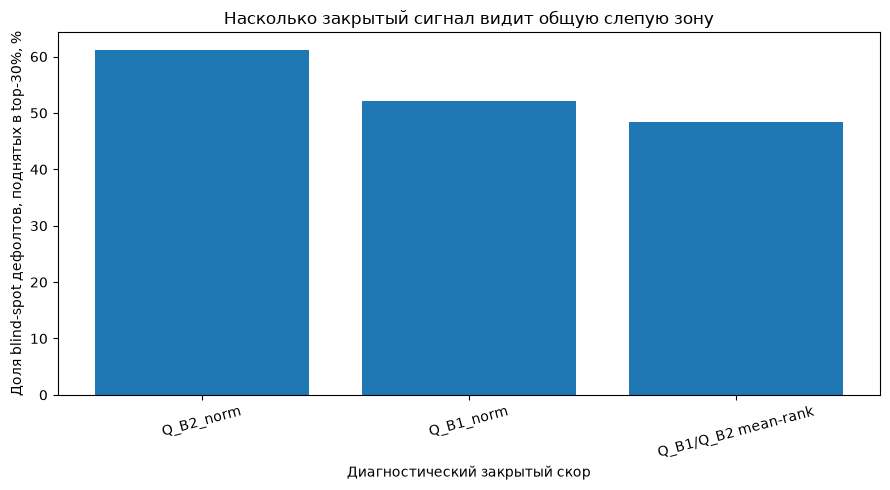

In [6]:
СКОРЫ_ДИАГНОСТИКИ = {
    "Q_B1_norm": РИСК_РАНГИ["Q_B1_norm"],
    "Q_B2_norm": РИСК_РАНГИ["Q_B2_norm"],
    "Q_B1/Q_B2 mean-rank": ЗАКРЫТЫЙ_CONSENSUS,
}

ГРУППЫ_ДЛЯ_RESCUE = {
    "Глубоко пропущенные дефолты": маска_глубокий_пропуск,
    "Общая слепая зона": маска_общая_слепая_зона,
}

ТОП_ДОЛИ = {
    "top-10%": 0.90,
    "top-20%": 0.80,
    "top-30%": 0.70,
}

строки_rescue = []

for группа, маска in ГРУППЫ_ДЛЯ_RESCUE.items():
    размер_группы = int(маска.sum())

    for скор_название, скор in СКОРЫ_ДИАГНОСТИКИ.items():
        for зона, граница in ТОП_ДОЛИ.items():
            спасено = int((маска & (скор >= граница)).sum())
            недефолты_помечены = int(
                (маска_недефолт & (скор >= граница)).sum()
            )

            строки_rescue.append({
                "Группа": группа,
                "Скор": скор_название,
                "Зона риска": зона,
                "Размер группы": размер_группы,
                "Спасено дефолтов": спасено,
                "Доля спасённых, %": спасено / размер_группы * 100,
                "Недефолтов в зоне": недефолты_помечены,
                "Доля всех недефолтов в зоне, %": (
                    недефолты_помечены / int(маска_недефолт.sum()) * 100
                ),
            })

ТАБЛИЦА_RESCUE = pd.DataFrame(строки_rescue)

display(
    ТАБЛИЦА_RESCUE[
        ТАБЛИЦА_RESCUE["Группа"] == "Общая слепая зона"
    ].round(2)
)

pivot_rescue = (
    ТАБЛИЦА_RESCUE[
        (ТАБЛИЦА_RESCUE["Группа"] == "Общая слепая зона")
        & (ТАБЛИЦА_RESCUE["Зона риска"] == "top-30%")
    ]
    .set_index("Скор")["Доля спасённых, %"]
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))
plt.bar(pivot_rescue.index, pivot_rescue.values)
plt.ylabel("Доля blind-spot дефолтов, поднятых в top-30%, %")
plt.xlabel("Диагностический закрытый скор")
plt.title("Насколько закрытый сигнал видит общую слепую зону")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# 6. Насколько закрытый сигнал противоречит baseline на blind spot

## Исследовательский вопрос

Закрытые индексы просто повторяют baseline или действительно ставят blind-spot дефолты существенно выше по риску?

Для каждой строки считаем:

`закрытый risk-rank − baseline consensus-rank`

Положительное значение означает: закрытый индекс видит **больше риска**, чем baseline.


In [7]:
def smd(
    значения_a: np.ndarray,
    значения_b: np.ndarray,
) -> float:
    """Standardized mean difference двух массивов."""
    a = np.asarray(значения_a, dtype=np.float64)
    b = np.asarray(значения_b, dtype=np.float64)

    var_a = float(np.var(a, ddof=1))
    var_b = float(np.var(b, ddof=1))
    pooled = np.sqrt((var_a + var_b) / 2)

    if pooled == 0:
        return 0.0

    return float((np.mean(a) - np.mean(b)) / pooled)


строки_разрыва = []

for название, закрытый_rank in СКОРЫ_ДИАГНОСТИКИ.items():
    разрыв = закрытый_rank - consensus_rank

    for группа, маска in {
        "Общая слепая зона": маска_общая_слепая_зона,
        "Хорошо ранжированные дефолты": маска_хороший_дефолт,
        "Все дефолты": маска_дефолт,
        "Все недефолты": маска_недефолт,
    }.items():
        строки_разрыва.append({
            "Скор": название,
            "Группа": группа,
            "Средний закрытый rank": float(np.mean(закрытый_rank[маска])),
            "Средний baseline rank": float(np.mean(consensus_rank[маска])),
            "Средний разрыв rank": float(np.mean(разрыв[маска])),
            "Медианный разрыв rank": float(np.median(разрыв[маска])),
        })

ТАБЛИЦА_РАЗРЫВА = pd.DataFrame(строки_разрыва)
display(ТАБЛИЦА_РАЗРЫВА.round(4))

строки_smd = []

for признак in ЗАКРЫТЫЕ_ИНДЕКСЫ:
    значения = закрытые_work[признак].to_numpy(dtype=np.float64)
    строки_smd.append({
        "Индекс": признак,
        "Среднее: blind spot": float(np.mean(значения[маска_общая_слепая_зона])),
        "Среднее: хорошо ранжированный дефолт": float(
            np.mean(значения[маска_хороший_дефолт])
        ),
        "SMD": smd(
            значения[маска_общая_слепая_зона],
            значения[маска_хороший_дефолт],
        ),
    })

ТАБЛИЦА_SMD_ЗАКРЫТЫХ = pd.DataFrame(строки_smd)
ТАБЛИЦА_SMD_ЗАКРЫТЫХ["|SMD|"] = ТАБЛИЦА_SMD_ЗАКРЫТЫХ["SMD"].abs()

print("Закрытые индексы: blind spot vs хорошо ранжированные дефолты")
display(ТАБЛИЦА_SMD_ЗАКРЫТЫХ.round(4))

for название, закрытый_rank in СКОРЫ_ДИАГНОСТИКИ.items():
    корреляция = float(
        pd.Series(consensus_rank).corr(
            pd.Series(закрытый_rank),
            method="spearman",
        )
    )
    print(
        f"Spearman baseline consensus ↔ {название}: "
        f"{корреляция:.3f}"
    )

,Скор,Группа,Средний закрытый rank,Средний baseline rank,Средний разрыв rank,Медианный разрыв rank
0,Q_B1_norm,Общая слепая зона,0.6628,0.3313,0.3316,0.4100
1,Q_B1_norm,Хорошо ранжированные дефолты,0.8975,0.9592,-0.0616,-0.0330
2,Q_B1_norm,Все дефолты,0.8633,0.8630,0.0003,0.0032
3,Q_B1_norm,Все недефолты,0.4611,0.4611,-0.0000,0.0038
4,Q_B2_norm,Общая слепая зона,0.6918,0.3313,0.3605,0.4405
5,Q_B2_norm,Хорошо ранжированные дефолты,0.8099,0.9592,-0.1493,-0.0158
6,Q_B2_norm,Все дефолты,0.8057,0.8630,-0.0573,0.0064
7,Q_B2_norm,Все недефолты,0.4673,0.4611,0.0061,0.0198
8,Q_B1/Q_B2 mean-rank,Общая слепая зона,0.6773,0.3313,0.3460,0.3681
9,Q_B1/Q_B2 mean-rank,Хорошо ранжированные дефолты,0.8537,0.9592,-0.1055,-0.0273


Закрытые индексы: blind spot vs хорошо ранжированные дефолты


,Индекс,Среднее: blind spot,Среднее: хорошо ранжированный дефолт,SMD,|SMD|
0,Q_B1_norm,-60.4553,-108.2770,0.5551,0.5551
1,Q_B2_norm,-70.9176,-105.2933,0.3306,0.3306


Spearman baseline consensus ↔ Q_B1_norm: 0.499
Spearman baseline consensus ↔ Q_B2_norm: 0.396
Spearman baseline consensus ↔ Q_B1/Q_B2 mean-rank: 0.525


# 7. Фиксированный oracle-check без оптимизации весов

## Исследовательский вопрос

Показывает ли простой **неоптимизированный** микс baseline-rank с закрытым risk-rank дополнительную ранжирующую информацию?

Мы заранее используем только простое арифметическое среднее. Никакие веса по target не подбираются.

Это **не кандидат production-модели**, потому что `Q_B1/Q_B2` запрещены. Это только проверка комплементарности сигнала.


In [8]:
ORACLE_СКОРЫ = {
    "Baseline consensus": consensus_rank,
    "Baseline + Q_B1 (1:1)": (
        consensus_rank + РИСК_РАНГИ["Q_B1_norm"]
    ) / 2,
    "Baseline + Q_B2 (1:1)": (
        consensus_rank + РИСК_РАНГИ["Q_B2_norm"]
    ) / 2,
    "Baseline + Q_B1 + Q_B2 (1:1:1)": (
        consensus_rank
        + РИСК_РАНГИ["Q_B1_norm"]
        + РИСК_РАНГИ["Q_B2_norm"]
    ) / 3,
}

строки_oracle = []

for название, скор in ORACLE_СКОРЫ.items():
    roc_auc = float(roc_auc_score(target, скор))
    строка = {
        "Скор": название,
        "ROC-AUC": roc_auc,
        "Gini": float(2 * roc_auc - 1),
        "PR-AUC": float(average_precision_score(target, скор)),
    }

    for зона, граница in ТОП_ДОЛИ.items():
        строка[f"Захват дефолтов {зона}, %"] = float(
            (скор[маска_дефолт] >= граница).mean() * 100
        )

    строки_oracle.append(строка)

ТАБЛИЦА_ORACLE = pd.DataFrame(строки_oracle)
display(ТАБЛИЦА_ORACLE.round(4))

,Скор,ROC-AUC,Gini,PR-AUC,"Захват дефолтов top-10%, %","Захват дефолтов top-20%, %","Захват дефолтов top-30%, %"
0,Baseline consensus,0.9032,0.8063,0.6038,57.2051,77.8297,87.3818
1,Baseline + Q_B1 (1:1),0.9377,0.8754,0.7705,56.9159,79.4646,89.7912
2,Baseline + Q_B2 (1:1),0.9225,0.8449,0.6876,47.2211,70.8085,76.9695
3,Baseline + Q_B1 + Q_B2 (1:1:1),0.9384,0.8768,0.7605,48.1135,69.9018,85.6720


# 8. Сохранение агрегированных результатов

В артефакты **не сохраняются**:

- `INN`;
- row-level значения `Q_B1/Q_B2`;
- final test;
- production-модель с закрытыми индексами.

Сохраняются только агрегированные диагностические результаты.


In [9]:
ПУТЬ_JSON = (
    ПАПКА_ОТЧЁТОВ
    / "stage4_closed_signal_diagnostics_V1.json"
)
ПУТЬ_RESCUE = (
    ПАПКА_ОТЧЁТОВ
    / "stage4_closed_signal_rescue_V1.csv"
)
ПУТЬ_ORACLE = (
    ПАПКА_ОТЧЁТОВ
    / "stage4_closed_signal_oracle_V1.csv"
)

ТАБЛИЦА_RESCUE.to_csv(
    ПУТЬ_RESCUE,
    index=False,
    encoding="utf-8-sig",
)
ТАБЛИЦА_ORACLE.to_csv(
    ПУТЬ_ORACLE,
    index=False,
    encoding="utf-8-sig",
)

версии = {
    пакет: importlib_metadata.version(пакет)
    for пакет in [
        "numpy",
        "pandas",
        "scikit-learn",
        "pyxlsb",
        "matplotlib",
    ]
}

результат = {
    "исследовательский_вопрос": (
        "Содержат ли Q_B1_norm и Q_B2_norm дополнительный сигнал "
        "именно в общей слепой зоне baseline без закрытых индексов?"
    ),
    "dataset": {
        "sha256": sha_dataset,
        "working_split_sha256": ОЖИДАЕМЫЙ_SHA_РАБОТА,
        "final_test_split_sha256": ОЖИДАЕМЫЙ_SHA_TEST,
        "final_test_использован": False,
    },
    "stage3_oof_checkpoint": {
        "filename": ПУТЬ_OOF.name,
        "sha256": sha_oof,
    },
    "группы_stage3": фактические_группы,
    "самостоятельный_сигнал": (
        ТАБЛИЦА_САМОСТОЯТЕЛЬНОГО_СИГНАЛА.to_dict(orient="records")
    ),
    "корреляция_qb1_qb2": {
        "pearson": pearson_raw,
        "spearman": spearman_raw,
    },
    "rescue": ТАБЛИЦА_RESCUE.to_dict(orient="records"),
    "rank_gap": ТАБЛИЦА_РАЗРЫВА.to_dict(orient="records"),
    "smd_closed_indices": ТАБЛИЦА_SMD_ЗАКРЫТЫХ.to_dict(orient="records"),
    "fixed_oracle_check": ТАБЛИЦА_ORACLE.to_dict(orient="records"),
    "ограничения": [
        "Q_B1_norm и Q_B2_norm запрещены в финальной рабочей модели.",
        "Индексы используются только как диагностический reference.",
        "Ориентация risk-score определена на working sample.",
        "Фиксированный oracle-mix не является production-кандидатом.",
        "Final test не использован.",
        "Ассоциация не доказывает причинность.",
    ],
    "версии_библиотек": версии,
}

with ПУТЬ_JSON.open("w", encoding="utf-8") as файл:
    json.dump(
        результат,
        файл,
        ensure_ascii=False,
        indent=2,
    )

print("Сохранено:")
print("-", ПУТЬ_JSON)
print("-", ПУТЬ_RESCUE)
print("-", ПУТЬ_ORACLE)

Сохранено:
- D:\Projects\komus-credit-risk\reports\generated\stage4_closed_signal_diagnostics_V1.json
- D:\Projects\komus-credit-risk\reports\generated\stage4_closed_signal_rescue_V1.csv
- D:\Projects\komus-credit-risk\reports\generated\stage4_closed_signal_oracle_V1.csv


# 9. Итог Stage 4 V1

## Как принимается решение

Ключевой показатель для выбора **направления следующей гипотезы**, а не модели — доля общей слепой зоны, которую закрытый индекс поднимает хотя бы в top-30% риска.

Если один индекс явно сильнее, следующая работа должна искать **прозрачные доступные прокси именно его типа сигнала**.

Если оба индекса дают сопоставимый rescue, следующим экспериментом нельзя смешивать десятки факторов: выбираем одну компактную группу, начиная с более интерпретируемой и воспроизводимой.


In [10]:
blind_top30 = (
    ТАБЛИЦА_RESCUE[
        (ТАБЛИЦА_RESCUE["Группа"] == "Общая слепая зона")
        & (ТАБЛИЦА_RESCUE["Зона риска"] == "top-30%")
        & (ТАБЛИЦА_RESCUE["Скор"].isin(["Q_B1_norm", "Q_B2_norm"]))
    ]
    .set_index("Скор")["Доля спасённых, %"]
)

rescue_qb1 = float(blind_top30["Q_B1_norm"])
rescue_qb2 = float(blind_top30["Q_B2_norm"])
разница_rescue = rescue_qb1 - rescue_qb2

if abs(разница_rescue) < 5.0:
    направление = (
        "Q_B1 и Q_B2 дают сопоставимый rescue. "
        "Следующий эксперимент должен выбрать одну прозрачную группу "
        "новых факторов после review обоих профилей."
    )
elif разница_rescue > 0:
    направление = (
        "Q_B1 сильнее поднимает blind-spot дефолты. "
        "Первый кандидат направления — прозрачные финансовые "
        "динамические признаки и ранние признаки ухудшения финансового состояния."
    )
else:
    направление = (
        "Q_B2 сильнее поднимает blind-spot дефолты. "
        "Первый кандидат направления — прозрачные признаки, "
        "связанные с должной осмотрительностью и внешними негативными событиями."
    )

print("ФАКТЫ")
print("-" * 72)
print(
    "Q_B1 standalone Gini:",
    f"{float(ТАБЛИЦА_САМОСТОЯТЕЛЬНОГО_СИГНАЛА.loc[ТАБЛИЦА_САМОСТОЯТЕЛЬНОГО_СИГНАЛА['Индекс'] == 'Q_B1_norm', 'Gini'].iloc[0]):.4f}",
)
print(
    "Q_B2 standalone Gini:",
    f"{float(ТАБЛИЦА_САМОСТОЯТЕЛЬНОГО_СИГНАЛА.loc[ТАБЛИЦА_САМОСТОЯТЕЛЬНОГО_СИГНАЛА['Индекс'] == 'Q_B2_norm', 'Gini'].iloc[0]):.4f}",
)
print(f"Pearson Q_B1 ↔ Q_B2: {pearson_raw:.3f}")
print(f"Spearman Q_B1 ↔ Q_B2: {spearman_raw:.3f}")
print(
    f"Blind spot rescue в top-30%: "
    f"Q_B1={rescue_qb1:.1f}%, Q_B2={rescue_qb2:.1f}%"
)

print("\nИНТЕРПРЕТАЦИЯ")
print("-" * 72)
print(направление)

print("\nОГРАНИЧЕНИЯ")
print("-" * 72)
print("- Закрытые индексы не становятся разрешёнными признаками.")
print("- Oracle-check не является новой production-моделью.")
print("- Анализ измеряет дополнительный сигнал, а не причинность.")
print("- Final test не использован.")
print("- Random split не доказывает temporal stability.")

print("\nСЛЕДУЮЩИЙ ШАГ")
print("-" * 72)
print(
    "По результату этого diagnostic gate формулируем ОДНУ первую "
    "гипотезу прозрачного feature engineering и сравниваем её "
    "с baseline Gini ≈ 0.804 на том же CV-протоколе."
)

ФАКТЫ
------------------------------------------------------------------------
Q_B1 standalone Gini: 0.8044
Q_B2 standalone Gini: 0.6768
Pearson Q_B1 ↔ Q_B2: 0.827
Spearman Q_B1 ↔ Q_B2: 0.405
Blind spot rescue в top-30%: Q_B1=52.2%, Q_B2=61.2%

ИНТЕРПРЕТАЦИЯ
------------------------------------------------------------------------
Q_B2 сильнее поднимает blind-spot дефолты. Первый кандидат направления — прозрачные признаки, связанные с должной осмотрительностью и внешними негативными событиями.

ОГРАНИЧЕНИЯ
------------------------------------------------------------------------
- Закрытые индексы не становятся разрешёнными признаками.
- Oracle-check не является новой production-моделью.
- Анализ измеряет дополнительный сигнал, а не причинность.
- Final test не использован.
- Random split не доказывает temporal stability.

СЛЕДУЮЩИЙ ШАГ
------------------------------------------------------------------------
По результату этого diagnostic gate формулируем ОДНУ первую гипотезу прозрачного